# DINOv2 Training-Free Dataset Pruning — Experimental Notebook

**Status: EXPERIMENTAL, not final thesis code.**

Covers Phase 0 (sanity check), Phase 1 (full vs random), Phase 2 (full vs DINOv2 pruning)
from the thesis experimental plan.

**NOT included in this notebook (deliberately, to avoid fabrication / premature complexity):**
- PRIME baseline (Phase 3) — needs a faithful reproduction, to be added as its own task.
- Representation / threshold / selection / model-size ablations (Phases 4–7).
- Multi-seed final experiments (Phase 8).

**Known-issue fixes applied here (see project context):**
- Similarity used directly as `S_ij = cosine(f_i, f_j)`, thresholded at `tau` — no `(S+1)/2` rescaling.
- Global retention budget `K = round(r * N)` enforced and **actual retention** measured and logged,
  not assumed to equal the target.
- Test set is never touched by feature extraction statistics, graph construction, thresholding,
  or pruning decisions — it is loaded only at final evaluation time.

**Environment:** Google Colab (T4) or Kaggle Notebook (P100). No local GPU assumed.

**Before running:** upload the Kvasir-SEG ZIP and set `KVASIR_ZIP_PATH` in the config cell below.
Expected internal structure: `images/` and `masks/` subfolders with matching filenames
(standard Kvasir-SEG layout). The extraction cell verifies this and fails loudly if it doesn't match —
it does not silently guess an alternate structure.


## 1. Environment setup

Run once per fresh Colab/Kaggle session.

In [1]:
# Colab/Kaggle setup. Safe to re-run.
import sys, subprocess

def pip_install(pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs])

# python-louvain provides the `community` package (Louvain algorithm on networkx graphs)
pip_install(["python-louvain", "networkx"])

print("Setup complete.")


Setup complete.


## 2. Imports

In [2]:
import os
import json
import random
import zipfile
import shutil
from pathlib import Path
from dataclasses import dataclass, asdict, field
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import networkx as nx
# import community as community_louvain  # python-louvain
from community import community_louvain

print("PyTorch:", torch.__version__)

print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


PyTorch: 2.11.0+cu128
Torch: 2.11.0+cu128 | CUDA available: True
Device: cuda


## 3. Config

Single source of truth for this run. Every experiment result row will embed a copy of this config
(or the relevant subset) so results are reproducible without cross-referencing notebook state.

In [3]:
@dataclass
class Config:
    # --- paths ---
    KVASIR_ZIP_PATH: str = "/content/kvasir-seg.zip"   # <-- SET THIS
    WORK_DIR: str = "/content/work"
    FEATURES_DIR: str = "/content/work/features"
    RESULTS_DIR: str = "/content/work/results"

    # --- reproducibility ---
    SEED: int = 42

    # --- split ---
    TRAIN_FRAC: float = 0.70
    VAL_FRAC: float = 0.10
    TEST_FRAC: float = 0.20

    # --- DINOv2 ---
    DINOV2_MODEL: str = "dinov2_vits14"   # ViT-S/14
    REPRESENTATION: str = "cls_meanpatch" # one of: cls | meanpatch | cls_meanpatch
    IMG_SIZE: int = 224                   # must be a multiple of 14 for ViT-S/14

    # --- similarity / graph ---
    SIMILARITY_THRESHOLD: float = 0.75    # tau, applied to RAW cosine similarity in [-1, 1]

    # --- pruning ---
    RETENTION_LEVELS: tuple = (0.10, 0.20, 0.30, 0.50, 1.00)
    METHODS: tuple = ("full", "random", "dinov2")

    # --- segmentation ---
    MASK_SIZE: int = 256
    BATCH_SIZE: int = 8
    EPOCHS: int = 30
    LR: float = 1e-3
    NUM_WORKERS: int = 2

    HARDWARE_NOTE: str = "SET MANUALLY: e.g. 'Colab T4' or 'Kaggle P100'"

CFG = Config()

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CFG.SEED)

for d in [CFG.WORK_DIR, CFG.FEATURES_DIR, CFG.RESULTS_DIR]:
    Path(d).mkdir(parents=True, exist_ok=True)

assert abs(CFG.TRAIN_FRAC + CFG.VAL_FRAC + CFG.TEST_FRAC - 1.0) < 1e-9, "Split fractions must sum to 1."
print(json.dumps(asdict(CFG), indent=2, default=str))


{
  "KVASIR_ZIP_PATH": "/content/kvasir-seg.zip",
  "WORK_DIR": "/content/work",
  "FEATURES_DIR": "/content/work/features",
  "RESULTS_DIR": "/content/work/results",
  "SEED": 42,
  "TRAIN_FRAC": 0.7,
  "VAL_FRAC": 0.1,
  "TEST_FRAC": 0.2,
  "DINOV2_MODEL": "dinov2_vits14",
  "REPRESENTATION": "cls_meanpatch",
  "IMG_SIZE": 224,
  "SIMILARITY_THRESHOLD": 0.75,
  "RETENTION_LEVELS": [
    0.1,
    0.2,
    0.3,
    0.5,
    1.0
  ],
  "METHODS": [
    "full",
    "random",
    "dinov2"
  ],
  "MASK_SIZE": 256,
  "BATCH_SIZE": 8,
  "EPOCHS": 30,
  "LR": 0.001,
  "NUM_WORKERS": 2,
  "HARDWARE_NOTE": "SET MANUALLY: e.g. 'Colab T4' or 'Kaggle P100'"
}


## 4. Load and verify Kvasir-SEG

Extracts the ZIP and verifies the expected `images/` + `masks/` structure. Does NOT silently fall back to a different structure — if it doesn't match, fix the path/layout or update this cell deliberately, don't let the notebook guess.

In [4]:
EXTRACT_DIR = Path(CFG.WORK_DIR) / "kvasir-seg"

if not EXTRACT_DIR.exists():
    assert Path(CFG.KVASIR_ZIP_PATH).exists(), (
        f"ZIP not found at {CFG.KVASIR_ZIP_PATH}. Upload it and update CFG.KVASIR_ZIP_PATH."
    )
    with zipfile.ZipFile(CFG.KVASIR_ZIP_PATH, "r") as zf:
        zf.extractall(EXTRACT_DIR)
    print(f"Extracted to {EXTRACT_DIR}")
else:
    print(f"Already extracted at {EXTRACT_DIR}")

# Locate images/ and masks/ anywhere under the extraction root (Kvasir-SEG ZIPs sometimes nest
# an extra top-level folder). We search rather than hardcode a single depth.
candidate_img_dirs = list(EXTRACT_DIR.rglob("images"))
candidate_mask_dirs = list(EXTRACT_DIR.rglob("masks"))

assert len(candidate_img_dirs) >= 1 and len(candidate_mask_dirs) >= 1, (
    "Could not find 'images/' and 'masks/' folders under the extracted ZIP. "
    "This notebook assumes the standard Kvasir-SEG layout and will NOT guess an alternate one. "
    f"Found under {EXTRACT_DIR}: {[p.name for p in EXTRACT_DIR.rglob('*') if p.is_dir()]}"
)

IMAGES_DIR = candidate_img_dirs[0]
MASKS_DIR = candidate_mask_dirs[0]
print("images dir:", IMAGES_DIR)
print("masks dir:", MASKS_DIR)

img_files = sorted([p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in (".jpg", ".jpeg", ".png")])
mask_files = {p.stem: p for p in MASKS_DIR.iterdir() if p.suffix.lower() in (".jpg", ".jpeg", ".png")}

missing_masks = [p.stem for p in img_files if p.stem not in mask_files]
assert not missing_masks, f"{len(missing_masks)} images have no matching mask, e.g. {missing_masks[:5]}"

records = [{"stem": p.stem, "image_path": str(p), "mask_path": str(mask_files[p.stem])} for p in img_files]
df_all = pd.DataFrame(records)
print(f"Total paired image/mask samples found: {len(df_all)}")
df_all.head()


Extracted to /content/work/kvasir-seg
images dir: /content/work/kvasir-seg/Kvasir-SEG/images
masks dir: /content/work/kvasir-seg/Kvasir-SEG/masks
Total paired image/mask samples found: 1000


,stem,image_path,mask_path
0,cju0qkwl35piu0993l0dewei2,/content/work/kvasir-seg/Kvasir-SEG/images/cju...,/content/work/kvasir-seg/Kvasir-SEG/masks/cju0...
1,cju0qoxqj9q6s0835b43399p4,/content/work/kvasir-seg/Kvasir-SEG/images/cju...,/content/work/kvasir-seg/Kvasir-SEG/masks/cju0...
2,cju0qx73cjw570799j4n5cjze,/content/work/kvasir-seg/Kvasir-SEG/images/cju...,/content/work/kvasir-seg/Kvasir-SEG/masks/cju0...
3,cju0roawvklrq0799vmjorwfv,/content/work/kvasir-seg/Kvasir-SEG/images/cju...,/content/work/kvasir-seg/Kvasir-SEG/masks/cju0...
4,cju0rx1idathl0835detmsp84,/content/work/kvasir-seg/Kvasir-SEG/images/cju...,/content/work/kvasir-seg/Kvasir-SEG/masks/cju0...


## 5. Train / validation / test split

70/10/20, seeded shuffle. This split is fixed for the rest of the notebook — every method/retention combination trains and evaluates on these exact same sets, so pruning method is the only thing that varies.

In [5]:
rng = np.random.RandomState(CFG.SEED)
indices = df_all.index.to_numpy().copy()
rng.shuffle(indices)

n = len(indices)
n_train = int(round(CFG.TRAIN_FRAC * n))
n_val = int(round(CFG.VAL_FRAC * n))
# remainder goes to test so counts sum exactly to n
n_test = n - n_train - n_val

train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

assert len(set(train_idx) & set(val_idx)) == 0
assert len(set(train_idx) & set(test_idx)) == 0
assert len(set(val_idx) & set(test_idx)) == 0

df_train = df_all.loc[train_idx].reset_index(drop=True)
df_val = df_all.loc[val_idx].reset_index(drop=True)
df_test = df_all.loc[test_idx].reset_index(drop=True)

print(f"train={len(df_train)}  val={len(df_val)}  test={len(df_test)}  (total={n})")

split_record = {
    "seed": CFG.SEED,
    "n_total": n,
    "n_train": len(df_train),
    "n_val": len(df_val),
    "n_test": len(df_test),
}
with open(Path(CFG.RESULTS_DIR) / "split_record.json", "w") as f:
    json.dump(split_record, f, indent=2)

df_train.to_csv(Path(CFG.WORK_DIR) / "split_train.csv", index=False)
df_val.to_csv(Path(CFG.WORK_DIR) / "split_val.csv", index=False)
df_test.to_csv(Path(CFG.WORK_DIR) / "split_test.csv", index=False)


train=700  val=100  test=200  (total=1000)


## 6. DINOv2 feature extraction (frozen)

Extracted **once**, saved to disk, and reused by every pruning experiment below — DINOv2 is not re-run per experiment. Extraction only ever touches `df_train`; val/test are never fed through this similarity pipeline.

In [6]:
dinov2 = torch.hub.load("facebookresearch/dinov2", CFG.DINOV2_MODEL)
dinov2.eval()
dinov2.to(DEVICE)
for p in dinov2.parameters():
    p.requires_grad_(False)

PATCH = 14
assert CFG.IMG_SIZE % PATCH == 0, "IMG_SIZE must be a multiple of 14 for ViT-S/14."

# Documented DINOv2 preprocessing: resize, ImageNet normalization.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

def load_and_preprocess(path, size):
    img = Image.open(path).convert("RGB").resize((size, size), Image.BILINEAR)
    arr = np.asarray(img).astype(np.float32) / 255.0
    arr = (arr - np.array(IMAGENET_MEAN)) / np.array(IMAGENET_STD)
    tensor = torch.from_numpy(arr).permute(2, 0, 1).float()
    return tensor

@torch.no_grad()
def extract_features(df, size=CFG.IMG_SIZE, batch_size=16):
    cls_feats, patch_feats = [], []
    n = len(df)
    for start in range(0, n, batch_size):
        batch_paths = df["image_path"].iloc[start:start + batch_size].tolist()
        batch = torch.stack([load_and_preprocess(p, size) for p in batch_paths]).to(DEVICE)
        out = dinov2.forward_features(batch)
        cls = out["x_norm_clstoken"]              # (B, 384)
        patch = out["x_norm_patchtokens"]          # (B, num_patches, 384)
        patch_mean = patch.mean(dim=1)             # (B, 384)
        cls_feats.append(cls.cpu().numpy())
        patch_feats.append(patch_mean.cpu().numpy())
        if start % (batch_size * 10) == 0:
            print(f"  extracted {start + len(batch_paths)}/{n}")
    return np.concatenate(cls_feats, axis=0), np.concatenate(patch_feats, axis=0)

cls_path = Path(CFG.FEATURES_DIR) / "train_cls.npy"
patch_path = Path(CFG.FEATURES_DIR) / "train_patch.npy"

if cls_path.exists() and patch_path.exists():
    print("Loading cached train features from disk.")
    train_cls = np.load(cls_path)
    train_patch = np.load(patch_path)
else:
    print(f"Extracting DINOv2 features for {len(df_train)} training images...")
    train_cls, train_patch = extract_features(df_train)
    np.save(cls_path, train_cls)
    np.save(patch_path, train_patch)

print("CLS shape:", train_cls.shape, "| patch-mean shape:", train_patch.shape)


Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 186MB/s]


Extracting DINOv2 features for 700 training images...
  extracted 16/700
  extracted 176/700
  extracted 336/700
  extracted 496/700
  extracted 656/700
CLS shape: (700, 384) | patch-mean shape: (700, 384)


## 7. Build representation + L2 normalize

In [7]:
def build_representation(cls, patch, mode):
    if mode == "cls":
        rep = cls
    elif mode == "meanpatch":
        rep = patch
    elif mode == "cls_meanpatch":
        rep = np.concatenate([cls, patch], axis=1)
    else:
        raise ValueError(f"Unknown representation mode: {mode}")
    norms = np.linalg.norm(rep, axis=1, keepdims=True)
    norms[norms == 0] = 1e-8  # guard against degenerate zero vectors
    return rep / norms

train_embeddings = build_representation(train_cls, train_patch, CFG.REPRESENTATION)
np.save(Path(CFG.FEATURES_DIR) / f"train_{CFG.REPRESENTATION}_l2norm.npy", train_embeddings)
print("Final embedding shape:", train_embeddings.shape, "(should be L2-normalized rows)")
print("Row norm check (first 5):", np.linalg.norm(train_embeddings[:5], axis=1))


Final embedding shape: (700, 768) (should be L2-normalized rows)
Row norm check (first 5): [1.        1.        1.        1.0000001 1.       ]


## 8. Cosine similarity + threshold graph

**Raw cosine similarity, no rescaling.** `S_ij = cosine(f_i, f_j) ∈ [-1, 1]`, and
`A_ij = 1` iff `S_ij >= tau`. This directly avoids Known Issue 1 (the old `(S+1)/2` transform).

In [8]:
def cosine_similarity_matrix(F_norm):
    # F_norm is already L2-normalized, so F @ F.T IS the cosine similarity matrix.
    return F_norm @ F_norm.T

S = cosine_similarity_matrix(train_embeddings)  # (N, N), values in [-1, 1]
np.fill_diagonal(S, -np.inf)  # remove self-loops before thresholding

assert np.allclose(S, S.T, atol=1e-5), "Similarity matrix is not symmetric — check embedding computation."

def build_threshold_graph(S, tau, node_ids):
    G = nx.Graph()
    G.add_nodes_from(node_ids)
    n = S.shape[0]
    iu, ju = np.triu_indices(n, k=1)  # upper triangle only, no self-loops, undirected by construction
    mask = S[iu, ju] >= tau
    edges = list(zip(node_ids[iu[mask]], node_ids[ju[mask]]))
    G.add_edges_from(edges)
    return G

node_ids = np.arange(len(df_train))
G = build_threshold_graph(S, CFG.SIMILARITY_THRESHOLD, node_ids)

n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
density = nx.density(G)
print(f"tau={CFG.SIMILARITY_THRESHOLD}  nodes={n_nodes}  edges={n_edges}  density={density:.4f}")

# Sanity: adjacency symmetry (networkx Graph is undirected by construction, but verify from matrix logic)
A = nx.to_numpy_array(G, nodelist=sorted(G.nodes()))
assert np.allclose(A, A.T), "Adjacency is not symmetric."


tau=0.75  nodes=700  edges=54002  density=0.2207


## 9. Louvain community detection

In [9]:
partition = community_louvain.best_partition(G, random_state=CFG.SEED)
# partition: dict node_id -> community_id

modularity = community_louvain.modularity(partition, G)
communities = {}
for node, comm in partition.items():
    communities.setdefault(comm, []).append(node)

sizes = sorted([len(v) for v in communities.values()], reverse=True)
singleton_count = sum(1 for s in sizes if s == 1)

graph_stats = {
    "tau": CFG.SIMILARITY_THRESHOLD,
    "n_nodes": n_nodes,
    "n_edges": n_edges,
    "density": density,
    "n_communities": len(communities),
    "modularity": modularity,
    "singleton_count": singleton_count,
    "largest_community_size": sizes[0] if sizes else 0,
    "community_size_distribution": sizes,
}
with open(Path(CFG.RESULTS_DIR) / "graph_stats.json", "w") as f:
    json.dump(graph_stats, f, indent=2)

print(f"communities={len(communities)}  modularity={modularity:.4f}  singletons={singleton_count}")
print("Top 10 community sizes:", sizes[:10])


communities=18  modularity=0.2253  singletons=13
Top 10 community sizes: [266, 243, 103, 73, 2, 1, 1, 1, 1, 1]


## 10. Pruning methods

**Global-budget degree-based selection** (fixes Known Issue 2). Target `K = round(r * N)` images are
selected in total, allocated across communities in proportion to community size (largest remainder
method for rounding), then within each community the highest-degree nodes are kept. If a community's
size is smaller than its allocation, all of its nodes are kept and the leftover budget is redistributed
proportionally among the remaining communities. This is done explicitly and logged — the actual
retained count is always measured, never assumed.

In [10]:
def allocate_budget_across_communities(communities: dict, K: int):
    '''
    Largest-remainder proportional allocation of a global budget K across communities,
    by community size. Returns dict comm_id -> num_to_select (<= size of that community).
    '''
    comm_ids = list(communities.keys())
    sizes = np.array([len(communities[c]) for c in comm_ids])
    total = sizes.sum()

    raw_alloc = sizes / total * K
    base_alloc = np.floor(raw_alloc).astype(int)
    remainder = raw_alloc - base_alloc

    remaining = K - base_alloc.sum()
    order = np.argsort(-remainder)  # largest remainder first
    for i in order[:remaining]:
        base_alloc[i] += 1

    # Clip to community size (can't select more nodes than exist in the community)
    alloc = {}
    leftover = 0
    for c, a, sz in zip(comm_ids, base_alloc, sizes):
        take = min(a, sz)
        alloc[c] = take
        leftover += (a - take)

    # Redistribute leftover budget (from communities that couldn't fill their quota)
    # among communities that still have unused capacity, largest-capacity-first.
    if leftover > 0:
        capacity = {c: len(communities[c]) - alloc[c] for c in comm_ids}
        cand = [c for c in comm_ids if capacity[c] > 0]
        cand.sort(key=lambda c: capacity[c], reverse=True)
        i = 0
        while leftover > 0 and cand:
            c = cand[i % len(cand)]
            if capacity[c] > 0:
                alloc[c] += 1
                capacity[c] -= 1
                leftover -= 1
            if capacity[c] == 0:
                cand.remove(c)
                if not cand:
                    break
                i = i % len(cand)
            else:
                i += 1

    return alloc


def prune_dinov2_degree(G, communities, retention: float, node_ids):
    N = len(node_ids)
    K = int(round(retention * N))
    K = min(K, N)

    alloc = allocate_budget_across_communities(communities, K)

    degree = dict(G.degree())
    selected = []
    for comm_id, take in alloc.items():
        members = communities[comm_id]
        members_sorted = sorted(members, key=lambda nd: (-degree.get(nd, 0), nd))  # deterministic tiebreak
        selected.extend(members_sorted[:take])

    return sorted(selected)


def prune_random(node_ids, retention: float, seed: int):
    N = len(node_ids)
    K = int(round(retention * N))
    r = np.random.RandomState(seed)
    selected = r.choice(node_ids, size=K, replace=False)
    return sorted(selected.tolist())


def prune_full(node_ids):
    return sorted(node_ids.tolist())


## 11. Build pruned subsets for each method × retention level, with actual retention logged

In [12]:
pruning_manifest = []  # one row per (method, target_retention) with the selected training indices

for retention in CFG.RETENTION_LEVELS:
    if retention >= 1.0:
        methods_this_level = ["full"]
    else:
        methods_this_level = ["random", "dinov2"]

    for method in methods_this_level:
        if method == "full":
            selected = prune_full(node_ids)
        elif method == "random":
            selected = prune_random(node_ids, retention, seed=CFG.SEED)
        elif method == "dinov2":
            selected = prune_dinov2_degree(G, communities, retention, node_ids)
        else:
            raise ValueError(method)

        actual_retention = len(selected) / len(node_ids)
        pruning_manifest.append({
            "method": method,
            "target_retention": retention,
            "n_selected": len(selected),
            "n_train_total": len(node_ids),
            "actual_retention": actual_retention,
            "selected_indices": [int(idx) for idx in selected], # Convert numpy.int64 to standard Python int
        })
        print(f"{method:8s} target={retention:.2f}  actual={actual_retention:.4f}  n={len(selected)}")

with open(Path(CFG.RESULTS_DIR) / "pruning_manifest.json", "w") as f:
    json.dump(pruning_manifest, f, indent=2)


random   target=0.10  actual=0.1000  n=70
dinov2   target=0.10  actual=0.1000  n=70
random   target=0.20  actual=0.2000  n=140
dinov2   target=0.20  actual=0.2000  n=140
random   target=0.30  actual=0.3000  n=210
dinov2   target=0.30  actual=0.3000  n=210
random   target=0.50  actual=0.5000  n=350
dinov2   target=0.50  actual=0.5000  n=350
full     target=1.00  actual=1.0000  n=700


## 12. Segmentation dataset / dataloader

In [13]:
class KvasirSegDataset(Dataset):
    def __init__(self, df, mask_size=CFG.MASK_SIZE, augment=False):
        self.df = df.reset_index(drop=True)
        self.mask_size = mask_size
        self.augment = augment  # placeholder: no augmentation implemented yet, flagged as a TODO below

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB").resize(
            (self.mask_size, self.mask_size), Image.BILINEAR)
        mask = Image.open(row["mask_path"]).convert("L").resize(
            (self.mask_size, self.mask_size), Image.NEAREST)

        img_arr = np.asarray(img).astype(np.float32) / 255.0
        img_arr = (img_arr - np.array(IMAGENET_MEAN)) / np.array(IMAGENET_STD)
        img_tensor = torch.from_numpy(img_arr).permute(2, 0, 1).float()

        mask_arr = (np.asarray(mask).astype(np.float32) / 255.0 > 0.5).astype(np.float32)
        mask_tensor = torch.from_numpy(mask_arr).unsqueeze(0).float()

        return img_tensor, mask_tensor

# NOTE: no data augmentation is implemented in this experimental notebook. The project context
# requires identical training procedure across compared methods, which holding augmentation OFF
# for everyone trivially satisfies. Add augmentation later only as a deliberate, documented choice
# applied identically to all methods.


## 13. Compact U-Net

In [14]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class CompactUNet(nn.Module):
    '''Small U-Net: 4 down / 4 up stages, base width 32. Sized for T4/P100 memory limits.'''
    def __init__(self, in_ch=3, out_ch=1, base=32):
        super().__init__()
        self.enc1 = DoubleConv(in_ch, base)
        self.enc2 = DoubleConv(base, base * 2)
        self.enc3 = DoubleConv(base * 2, base * 4)
        self.enc4 = DoubleConv(base * 4, base * 8)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base * 8, base * 16)

        self.up4 = nn.ConvTranspose2d(base * 16, base * 8, 2, stride=2)
        self.dec4 = DoubleConv(base * 16, base * 8)
        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
        self.dec3 = DoubleConv(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.dec2 = DoubleConv(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.dec1 = DoubleConv(base * 2, base)

        self.out_conv = nn.Conv2d(base, out_ch, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))

        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.out_conv(d1)  # logits, shape (B, 1, H, W)


## 14. Losses

In [15]:
def dice_loss(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    probs = probs.view(probs.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    intersection = (probs * targets).sum(dim=1)
    union = probs.sum(dim=1) + targets.sum(dim=1)
    dice = (2 * intersection + eps) / (union + eps)
    return 1 - dice.mean()

def bce_dice_loss(logits, targets):
    bce = F.binary_cross_entropy_with_logits(logits, targets)
    dl = dice_loss(logits, targets)
    return bce + dl


## 15. Training + evaluation functions

In [16]:
def train_unet(train_df, val_df, cfg: Config, seed: int, log_prefix: str = ""):
    set_seed(seed)

    train_ds = KvasirSegDataset(train_df)
    val_ds = KvasirSegDataset(val_df)
    train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,
                               num_workers=cfg.NUM_WORKERS, drop_last=False)
    val_loader = DataLoader(val_ds, batch_size=cfg.BATCH_SIZE, shuffle=False,
                             num_workers=cfg.NUM_WORKERS)

    model = CompactUNet().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.LR)

    history = []
    for epoch in range(cfg.EPOCHS):
        model.train()
        running_loss = 0.0
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            logits = model(imgs)
            loss = bce_dice_loss(logits, masks)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
        train_loss = running_loss / len(train_ds)

        val_metrics = evaluate_unet(model, val_loader)
        history.append({"epoch": epoch, "train_loss": train_loss, **val_metrics})
        print(f"{log_prefix} epoch {epoch+1}/{cfg.EPOCHS}  "
              f"train_loss={train_loss:.4f}  val_dice={val_metrics['dice']:.4f}  val_iou={val_metrics['iou']:.4f}")

    return model, history


@torch.no_grad()
def evaluate_unet(model, loader, threshold=0.5, eps=1e-6):
    model.eval()
    dice_sum, iou_sum, prec_sum, rec_sum, n = 0.0, 0.0, 0.0, 0.0, 0

    for imgs, masks in loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        logits = model(imgs)
        preds = (torch.sigmoid(logits) > threshold).float()

        preds_flat = preds.view(preds.size(0), -1)
        masks_flat = masks.view(masks.size(0), -1)

        intersection = (preds_flat * masks_flat).sum(dim=1)
        union = preds_flat.sum(dim=1) + masks_flat.sum(dim=1) - intersection

        dice = (2 * intersection + eps) / (preds_flat.sum(dim=1) + masks_flat.sum(dim=1) + eps)
        iou = (intersection + eps) / (union + eps)
        precision = (intersection + eps) / (preds_flat.sum(dim=1) + eps)
        recall = (intersection + eps) / (masks_flat.sum(dim=1) + eps)

        bs = imgs.size(0)
        dice_sum += dice.sum().item()
        iou_sum += iou.sum().item()
        prec_sum += precision.sum().item()
        rec_sum += recall.sum().item()
        n += bs

    return {
        "dice": dice_sum / n,
        "iou": iou_sum / n,
        "precision": prec_sum / n,
        "recall": rec_sum / n,
    }


## 16. Experiment runner

Loops over every (method, retention) combination from the pruning manifest, trains a U-Net with an
identical procedure for all of them, evaluates on the held-out val and **untouched** test sets, and
logs a full reproducibility record per run.

In [17]:
import time

results = []

for entry in pruning_manifest:
    method = entry["method"]
    target_retention = entry["target_retention"]
    actual_retention = entry["actual_retention"]
    selected_idx = entry["selected_indices"]

    run_train_df = df_train.iloc[selected_idx].reset_index(drop=True)
    log_prefix = f"[{method} target={target_retention:.2f} actual={actual_retention:.3f}]"
    print(f"\n=== {log_prefix} n_train={len(run_train_df)} ===")

    t0 = time.time()
    model, history = train_unet(run_train_df, df_val, CFG, seed=CFG.SEED, log_prefix=log_prefix)
    train_time_sec = time.time() - t0

    val_metrics = evaluate_unet(model, DataLoader(KvasirSegDataset(df_val), batch_size=CFG.BATCH_SIZE))
    test_metrics = evaluate_unet(model, DataLoader(KvasirSegDataset(df_test), batch_size=CFG.BATCH_SIZE))

    record = {
        "seed": CFG.SEED,
        "n_train_total_pool": len(df_train),
        "n_val": len(df_val),
        "n_test": len(df_test),
        "method": method,
        "target_retention": target_retention,
        "actual_retention": actual_retention,
        "n_retained": len(selected_idx),
        "dinov2_model": CFG.DINOV2_MODEL,
        "representation": CFG.REPRESENTATION,
        "embedding_dim": train_embeddings.shape[1],
        "img_size": CFG.IMG_SIZE,
        "similarity_threshold": CFG.SIMILARITY_THRESHOLD if method == "dinov2" else None,
        "graph_n_nodes": graph_stats["n_nodes"] if method == "dinov2" else None,
        "graph_n_edges": graph_stats["n_edges"] if method == "dinov2" else None,
        "graph_density": graph_stats["density"] if method == "dinov2" else None,
        "n_communities": graph_stats["n_communities"] if method == "dinov2" else None,
        "modularity": graph_stats["modularity"] if method == "dinov2" else None,
        "singleton_count": graph_stats["singleton_count"] if method == "dinov2" else None,
        "pruning_method": method,
        "segmentation_arch": "CompactUNet(base=32)",
        "loss": "BCE+Dice",
        "optimizer": "Adam",
        "lr": CFG.LR,
        "epochs": CFG.EPOCHS,
        "batch_size": CFG.BATCH_SIZE,
        "hardware": CFG.HARDWARE_NOTE,
        "train_time_sec": train_time_sec,
        "val_dice": val_metrics["dice"],
        "val_iou": val_metrics["iou"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "test_dice": test_metrics["dice"],
        "test_iou": test_metrics["iou"],
        "test_precision": test_metrics["precision"],
        "test_recall": test_metrics["recall"],
    }
    results.append(record)

    # persist incrementally so a crash mid-sweep doesn't lose completed runs
    pd.DataFrame(results).to_csv(Path(CFG.RESULTS_DIR) / "experiment_results.csv", index=False)

results_df = pd.DataFrame(results)
results_df



=== [random target=0.10 actual=0.100] n_train=70 ===
[random target=0.10 actual=0.100] epoch 1/30  train_loss=1.4624  val_dice=0.3212  val_iou=0.2139
[random target=0.10 actual=0.100] epoch 2/30  train_loss=1.3203  val_dice=0.3833  val_iou=0.2607
[random target=0.10 actual=0.100] epoch 3/30  train_loss=1.2601  val_dice=0.3501  val_iou=0.2340
[random target=0.10 actual=0.100] epoch 4/30  train_loss=1.2172  val_dice=0.2760  val_iou=0.1786
[random target=0.10 actual=0.100] epoch 5/30  train_loss=1.1883  val_dice=0.3557  val_iou=0.2430
[random target=0.10 actual=0.100] epoch 6/30  train_loss=1.1511  val_dice=0.3285  val_iou=0.2152
[random target=0.10 actual=0.100] epoch 7/30  train_loss=1.1516  val_dice=0.3671  val_iou=0.2515
[random target=0.10 actual=0.100] epoch 8/30  train_loss=1.1270  val_dice=0.3180  val_iou=0.2077
[random target=0.10 actual=0.100] epoch 9/30  train_loss=1.1036  val_dice=0.4109  val_iou=0.2900
[random target=0.10 actual=0.100] epoch 10/30  train_loss=1.0672  val_dic

,seed,n_train_total_pool,n_val,n_test,method,target_retention,actual_retention,n_retained,dinov2_model,representation,...,hardware,train_time_sec,val_dice,val_iou,val_precision,val_recall,test_dice,test_iou,test_precision,test_recall
0,42,700,100,200,random,0.1,0.1,70,dinov2_vits14,cls_meanpatch,...,SET MANUALLY: e.g. 'Colab T4' or 'Kaggle P100',103.823560,0.509335,0.380629,0.561944,0.598216,0.407195,0.297551,0.587781,0.462486
1,42,700,100,200,dinov2,0.1,0.1,70,dinov2_vits14,cls_meanpatch,...,SET MANUALLY: e.g. 'Colab T4' or 'Kaggle P100',104.537506,0.506794,0.371534,0.421883,0.856568,0.460702,0.336405,0.429480,0.710737
2,42,700,100,200,random,0.2,0.2,140,dinov2_vits14,cls_meanpatch,...,SET MANUALLY: e.g. 'Colab T4' or 'Kaggle P100',157.662677,0.483880,0.351972,0.395901,0.856437,0.487198,0.352684,0.425595,0.793586
3,42,700,100,200,dinov2,0.2,0.2,140,dinov2_vits14,cls_meanpatch,...,SET MANUALLY: e.g. 'Colab T4' or 'Kaggle P100',157.844993,0.519322,0.382802,0.492345,0.739517,0.495447,0.367471,0.534088,0.652427
4,42,700,100,200,random,0.3,0.3,210,dinov2_vits14,cls_meanpatch,...,SET MANUALLY: e.g. 'Colab T4' or 'Kaggle P100',210.822381,0.586171,0.459744,0.601302,0.687360,0.522815,0.396747,0.605613,0.579193
5,42,700,100,200,dinov2,0.3,0.3,210,dinov2_vits14,cls_meanpatch,...,SET MANUALLY: e.g. 'Colab T4' or 'Kaggle P100',210.827704,0.566086,0.444660,0.586662,0.733698,0.490959,0.378224,0.614469,0.602326
6,42,700,100,200,random,0.5,0.5,350,dinov2_vits14,cls_meanpatch,...,SET MANUALLY: e.g. 'Colab T4' or 'Kaggle P100',321.031429,0.660821,0.540362,0.683358,0.746203,0.568330,0.450359,0.668407,0.642293
7,42,700,100,200,dinov2,0.5,0.5,350,dinov2_vits14,cls_meanpatch,...,SET MANUALLY: e.g. 'Colab T4' or 'Kaggle P100',320.451080,0.657684,0.530170,0.664797,0.754812,0.571882,0.446187,0.633684,0.655662
8,42,700,100,200,full,1.0,1.0,700,dinov2_vits14,cls_meanpatch,...,SET MANUALLY: e.g. 'Colab T4' or 'Kaggle P100',593.618733,0.711473,0.607674,0.766504,0.736504,0.666259,0.550283,0.742542,0.702161


## 17. Save final results

In [18]:
results_df.to_csv(Path(CFG.RESULTS_DIR) / "experiment_results.csv", index=False)
with open(Path(CFG.RESULTS_DIR) / "experiment_results.json", "w") as f:
    json.dump(results, f, indent=2, default=str)
print(f"Saved {len(results_df)} experiment rows to {CFG.RESULTS_DIR}")


Saved 9 experiment rows to /content/work/results


## 18. Visualization: retention vs Dice / IoU

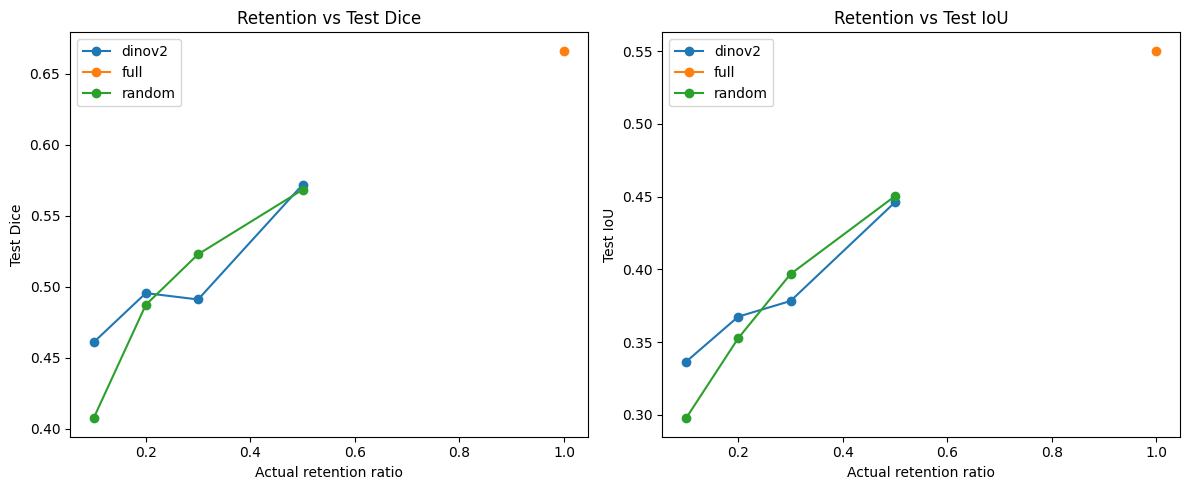

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for method, group in results_df.groupby("method"):
    group_sorted = group.sort_values("actual_retention")
    axes[0].plot(group_sorted["actual_retention"], group_sorted["test_dice"], marker="o", label=method)
    axes[1].plot(group_sorted["actual_retention"], group_sorted["test_iou"], marker="o", label=method)

axes[0].set_xlabel("Actual retention ratio")
axes[0].set_ylabel("Test Dice")
axes[0].set_title("Retention vs Test Dice")
axes[0].legend()

axes[1].set_xlabel("Actual retention ratio")
axes[1].set_ylabel("Test IoU")
axes[1].set_title("Retention vs Test IoU")
axes[1].legend()

plt.tight_layout()
plt.savefig(Path(CFG.RESULTS_DIR) / "retention_vs_metrics.png", dpi=150)
plt.show()


## 19. What this notebook does NOT yet answer

Do not draw thesis conclusions from this notebook alone. Specifically still missing:

- **PRIME baseline** (Phase 3) — not implemented here. Needs a deliberate, documented reproduction.
- **Representation ablation** (CLS vs mean-patch vs CLS+mean-patch) — Phase 4.
- **Threshold ablation** across tau values — Phase 5, and must not use the test set to pick tau.
- **Selection ablation** (degree vs centroid/medoid) — Phase 6.
- **Model-size ablation** (ViT-S/14 vs ViT-B/14) — Phase 7.
- **Multi-seed runs with mean ± std** — Phase 8. Everything above is a single seed (42) and should
  be read as a development/sanity result, not a final comparison.
- **Failure analysis** (does DINOv2 pruning disproportionately remove small polyps, rare shapes, etc.)
  — needs qualitative inspection of which images were dropped at each retention level, not done here.

Next task after this notebook runs successfully: inspect `experiment_results.csv`, confirm
`actual_retention` is close to `target_retention` for the DINOv2 method (it may legitimately differ —
that's expected and must be reported honestly, not hidden), and update `THESIS_STATE.md`.
